In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from src.dataset import (
    get_record_names,
    load_record,
    load_annotations,
    get_record_info,
    build_record_metadata,
    build_annotation_distribution,
)

from src.visualization import (
    plot_ecg,
    plot_two_channel_ecg,
    plot_annotation_distribution,
)

In [2]:
print("Project root:")
print(PROJECT_ROOT)

print("\nContents:")
for item in PROJECT_ROOT.iterdir():
    print(item.name)

Project root:
/home/raju/thesis_project

Contents:
logs
notebooks
results
experiments
src
data
README.md
configs
.venv


In [3]:
DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "mit-bih-arrhythmia-database-1.0.0"
)

print(DATA_DIR)
print(DATA_DIR.exists())

/home/raju/thesis_project/data/raw/mit-bih-arrhythmia-database-1.0.0
True


In [4]:
records = get_record_names(
    str(DATA_DIR)
)

print(
    f"Number of records: {len(records)}"
)

print("\nRecord names:")
print(records)

Number of records: 48

Record names:
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [5]:
record_name = "100"

record = load_record(
    record_name,
    str(DATA_DIR)
)

print("Record:", record_name)
print("Sampling frequency:", record.fs)
print("Signal shape:", record.p_signal.shape)
print("Channels:", record.sig_name)
print("Units:", record.units)
print("ADC gain:", record.adc_gain)
print("Baseline:", record.baseline)

Record: 100
Sampling frequency: 360
Signal shape: (650000, 2)
Channels: ['MLII', 'V5']
Units: ['mV', 'mV']
ADC gain: [200.0, 200.0]
Baseline: [1024, 1024]


In [6]:
signal = record.p_signal

print(
    "Number of samples:",
    signal.shape[0]
)

print(
    "Number of channels:",
    signal.shape[1]
)

print(
    "Duration:",
    signal.shape[0] / record.fs,
    "seconds"
)

print(
    "Duration:",
    signal.shape[0] / record.fs / 60,
    "minutes"
)

print(
    "Minimum amplitude:",
    np.min(signal)
)

print(
    "Maximum amplitude:",
    np.max(signal)
)

print(
    "Mean amplitude:",
    np.mean(signal)
)

print(
    "Standard deviation:",
    np.std(signal)
)

Number of samples: 650000
Number of channels: 2
Duration: 1805.5555555555557 seconds
Duration: 30.092592592592595 minutes
Minimum amplitude: -2.715
Maximum amplitude: 1.435
Mean amplitude: -0.24866670384615383
Standard deviation: 0.18157117166295547


In [7]:
print(
    "NaN values:",
    np.isnan(signal).sum()
)

print(
    "Infinite values:",
    np.isinf(signal).sum()
)

NaN values: 0
Infinite values: 0


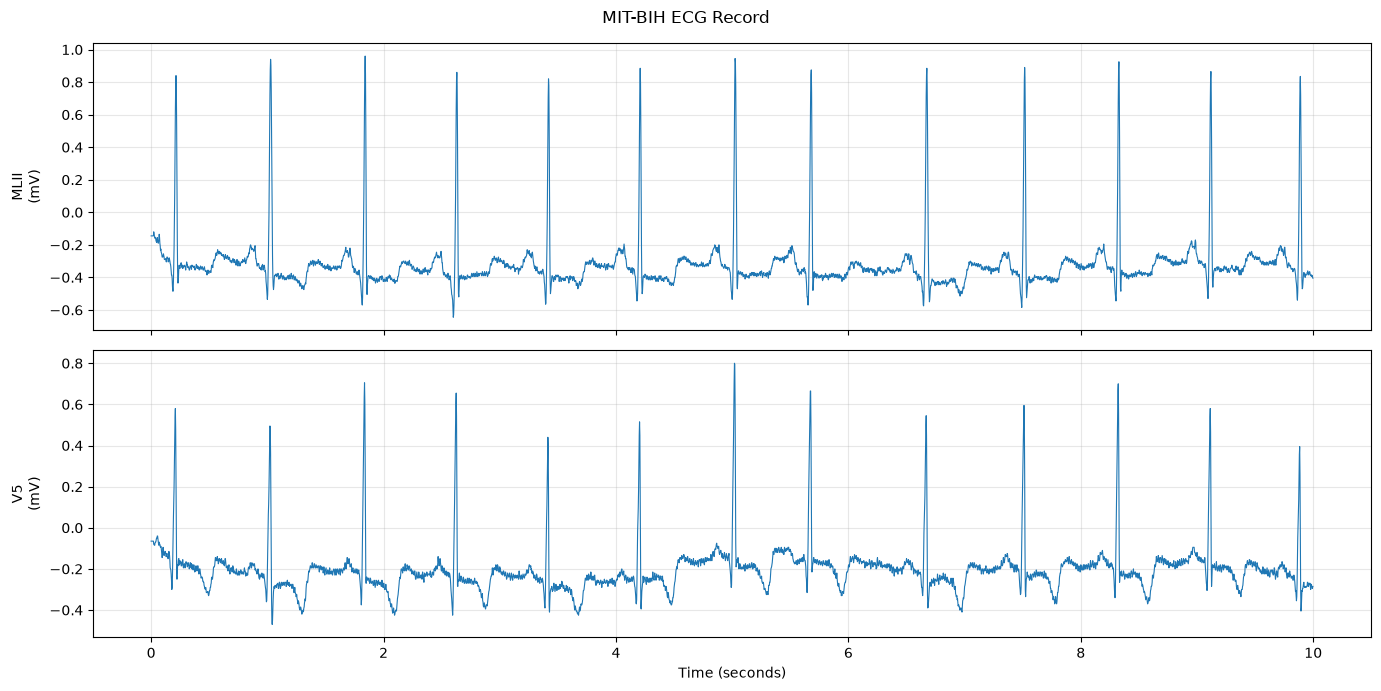

In [8]:
plot_two_channel_ecg(
    record,
    start_seconds=0,
    duration_seconds=10
)

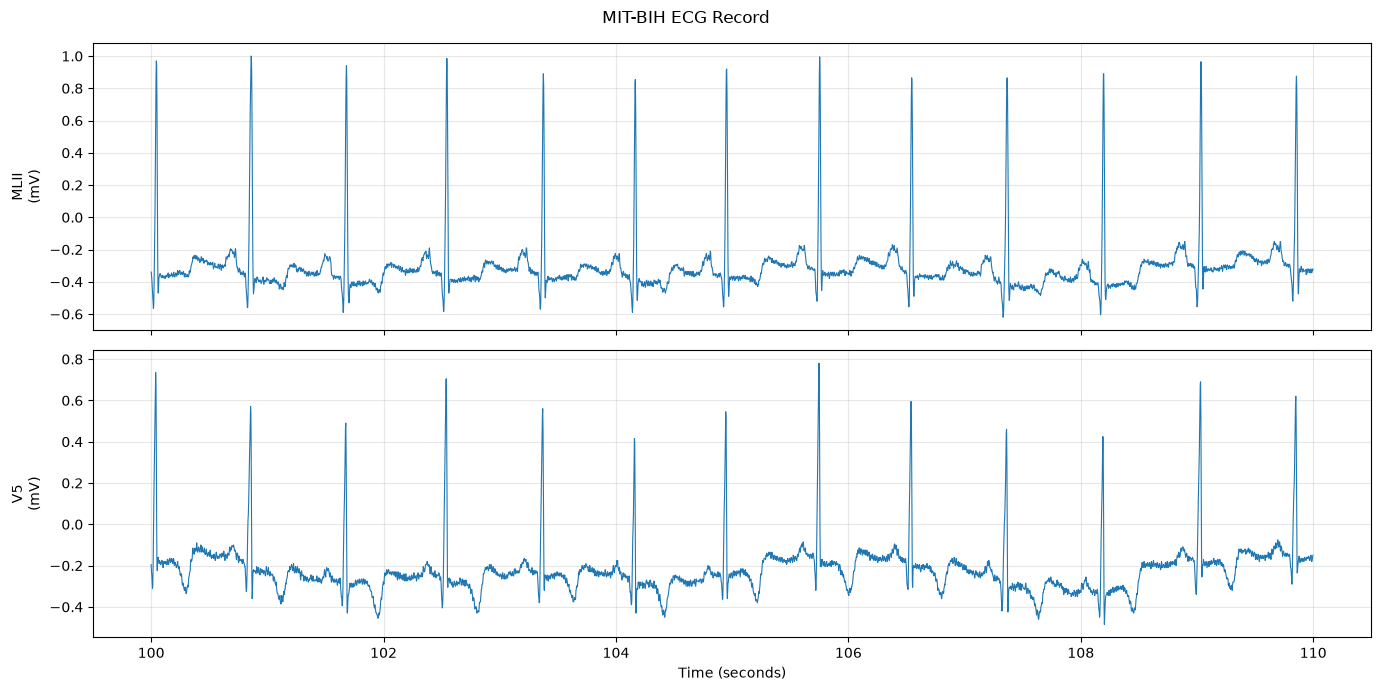

In [9]:
plot_two_channel_ecg(
    record,
    start_seconds=100,
    duration_seconds=10
)

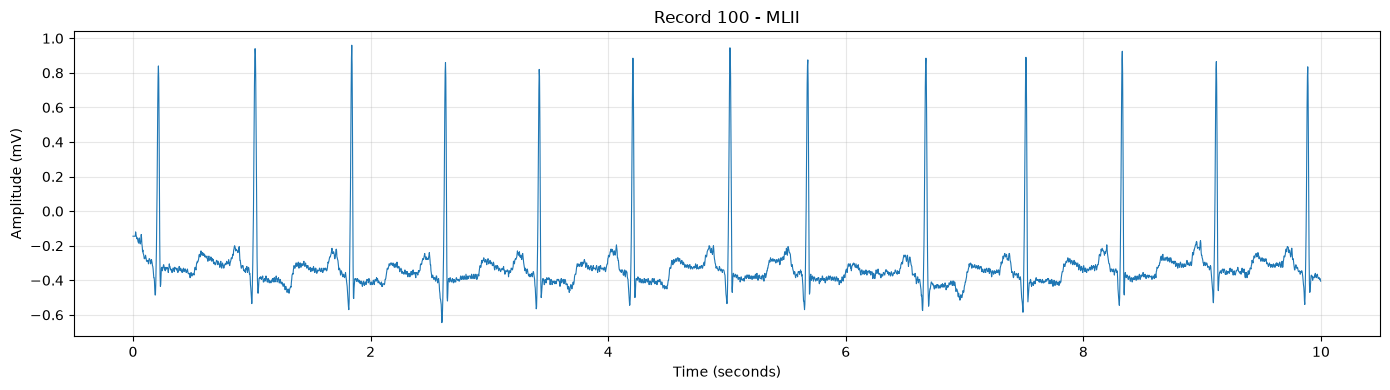

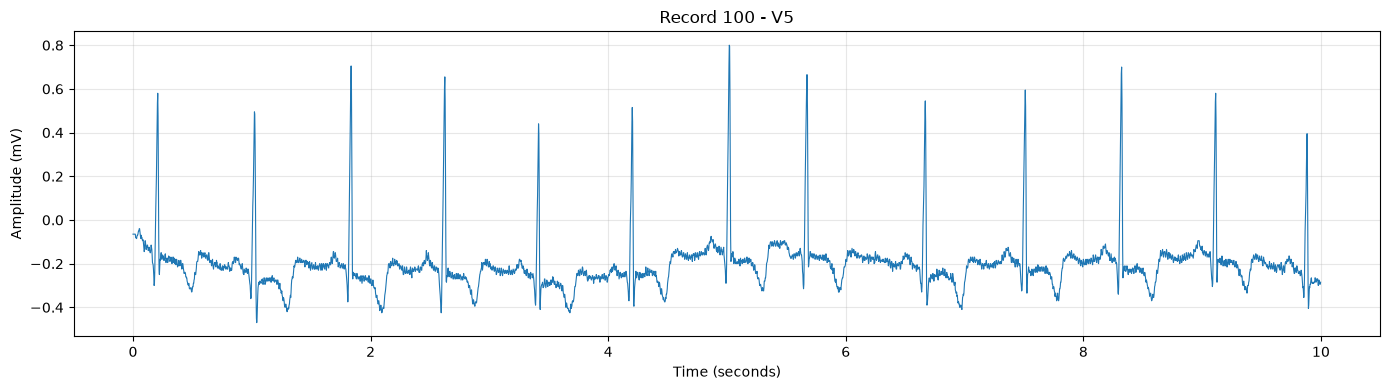

In [10]:
for channel_index, channel_name in enumerate(record.sig_name):

    plot_ecg(
        signal=record.p_signal[:, channel_index],
        fs=record.fs,
        channel_name=channel_name,
        start_seconds=0,
        duration_seconds=10,
        title=f"Record {record_name} - {channel_name}"
    )

In [12]:
annotation = load_annotations(
    record_name,
    str(DATA_DIR)
)

print(
    "Number of annotations:",
    len(annotation.sample)
)

print(
    "First annotation locations:"
)

print(
    annotation.sample[:20]
)

print(
    "\nFirst annotation symbols:"
)

print(
    annotation.symbol[:20]
)

Number of annotations: 2274
First annotation locations:
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]

First annotation symbols:
['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [13]:
annotation_df = pd.DataFrame({
    "sample": annotation.sample,
    "symbol": annotation.symbol
})

annotation_df.head(20)

,sample,symbol
0,18,+
1,77,N
2,370,N
3,662,N
4,946,N
5,1231,N
6,1515,N
7,1809,N
8,2044,A
9,2402,N


In [14]:
annotation_df["time_seconds"] = (
    annotation_df["sample"] / record.fs
)

annotation_df.head(20)

,sample,symbol,time_seconds
0,18,+,0.050000
1,77,N,0.213889
2,370,N,1.027778
3,662,N,1.838889
4,946,N,2.627778
5,1231,N,3.419444
6,1515,N,4.208333
7,1809,N,5.025000
8,2044,A,5.677778
9,2402,N,6.672222


In [15]:
symbol_counts = (
    annotation_df["symbol"]
    .value_counts()
)

symbol_counts

symbol
N    2239
A      33
+       1
V       1
Name: count, dtype: int64

In [16]:
symbol_distribution = pd.DataFrame({
    "count": symbol_counts,
    "percentage": (
        symbol_counts
        / symbol_counts.sum()
        * 100
    )
})

symbol_distribution

,count,percentage
symbol,,
N,2239,98.460862
A,33,1.451187
+,1,0.043975
V,1,0.043975


In [17]:
all_annotation_distribution = (
    build_annotation_distribution(
        str(DATA_DIR)
    )
)

all_annotation_distribution.head(20)

,symbol,count,percentage
0,N,75052,66.625831
1,L,8075,7.168411
2,R,7259,6.444024
3,V,7130,6.329507
4,/,7028,6.238959
5,A,2546,2.260158
6,+,1291,1.146058
7,f,982,0.871750
8,F,803,0.712846
9,~,616,0.546841


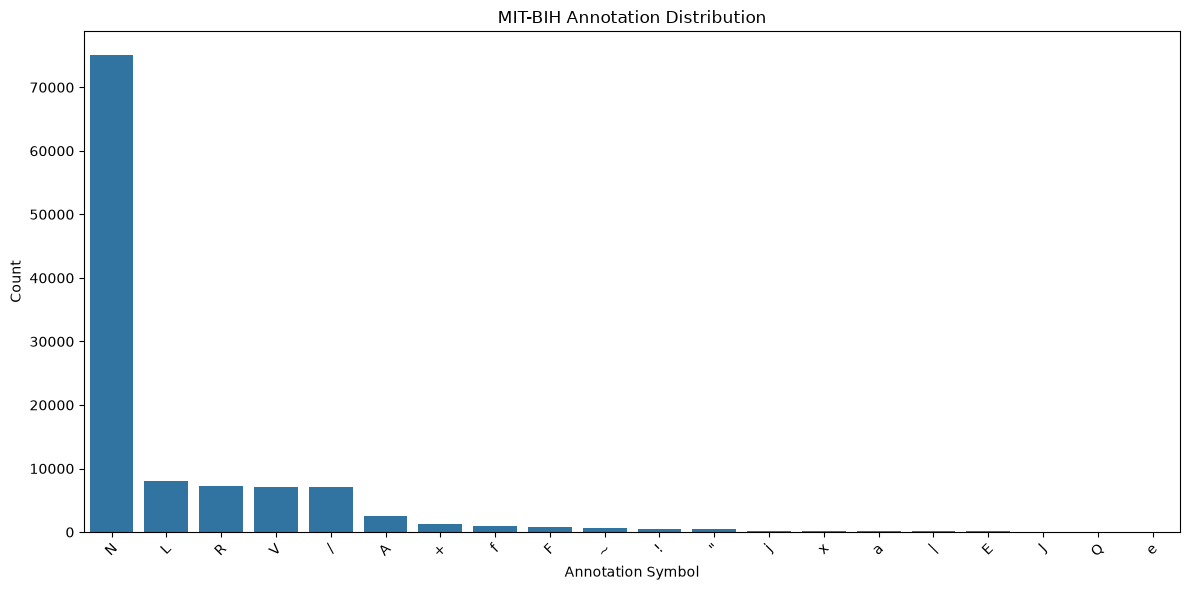

In [18]:
plot_annotation_distribution(
    all_annotation_distribution,
    top_n=20
)

In [19]:
metadata = build_record_metadata(
    str(DATA_DIR)
)

metadata

,record_id,sampling_frequency,number_of_samples,number_of_channels,channel_names,duration_seconds,duration_minutes,number_of_annotations,min_amplitude,max_amplitude,mean_amplitude,std_amplitude,nan_count,inf_count,status,error
0,100,360,650000,2,"MLII,V5",1805.555556,30.092593,2274,-2.715,1.435,-0.248667,0.181571,0,0,OK,
1,101,360,650000,2,"MLII,V1",1805.555556,30.092593,1874,-3.175,2.420,-0.181168,0.214342,0,0,OK,
2,102,360,650000,2,"V5,V2",1805.555556,30.092593,2192,-3.370,2.535,-0.116636,0.829847,0,0,OK,
3,103,360,650000,2,"MLII,V2",1805.555556,30.092593,2091,-5.120,5.115,-0.092207,0.554285,0,0,OK,
4,104,360,650000,2,"V5,V2",1805.555556,30.092593,2311,-1.935,1.975,-0.076740,0.271685,0,0,OK,
5,105,360,650000,2,"MLII,V1",1805.555556,30.092593,2691,-3.715,3.000,-0.072118,0.380126,0,0,OK,
6,106,360,650000,2,"MLII,V1",1805.555556,30.092593,2098,-2.665,2.570,-0.081141,0.294147,0,0,OK,
7,107,360,650000,2,"MLII,V1",1805.555556,30.092593,2140,-3.375,3.465,-0.069055,0.762791,0,0,OK,
8,108,360,650000,2,"MLII,V1",1805.555556,30.092593,1824,-4.490,3.150,-0.060573,0.448354,0,0,OK,
9,109,360,650000,2,"MLII,V1",1805.555556,30.092593,2535,-3.195,3.130,-0.061432,0.456324,0,0,OK,


In [20]:
metadata.shape

(48, 16)

In [21]:
metadata[
    [
        "record_id",
        "sampling_frequency",
        "number_of_samples",
        "number_of_channels",
        "channel_names",
        "duration_minutes",
        "number_of_annotations"
    ]
]

,record_id,sampling_frequency,number_of_samples,number_of_channels,channel_names,duration_minutes,number_of_annotations
0,100,360,650000,2,"MLII,V5",30.092593,2274
1,101,360,650000,2,"MLII,V1",30.092593,1874
2,102,360,650000,2,"V5,V2",30.092593,2192
3,103,360,650000,2,"MLII,V2",30.092593,2091
4,104,360,650000,2,"V5,V2",30.092593,2311
5,105,360,650000,2,"MLII,V1",30.092593,2691
6,106,360,650000,2,"MLII,V1",30.092593,2098
7,107,360,650000,2,"MLII,V1",30.092593,2140
8,108,360,650000,2,"MLII,V1",30.092593,1824
9,109,360,650000,2,"MLII,V1",30.092593,2535


In [22]:
METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata"
)

METADATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [23]:
metadata.to_csv(
    METADATA_DIR / "record_metadata.csv",
    index=False
)

print(
    "Saved:",
    METADATA_DIR / "record_metadata.csv"
)

Saved: /home/raju/thesis_project/data/processed/metadata/record_metadata.csv


In [24]:
all_annotation_distribution.to_csv(
    METADATA_DIR / "annotation_distribution.csv",
    index=False
)

print(
    "Saved annotation distribution."
)

Saved annotation distribution.


In [26]:
print("========== DATASET INTEGRITY ==========")

print(
    "Expected records:",
    48
)

print(
    "Discovered records:",
    len(records)
)

print(
    "Successfully loaded:",
    (metadata["status"] == "OK").sum()
)

print(
    "Failed:",
    (metadata["status"] == "FAILED").sum()
)

========== DATASET INTEGRITY ==========
Expected records: 48
Discovered records: 48
Successfully loaded: 48
Failed: 0


In [27]:
print("\nSampling frequencies:")
print(
    metadata[
        metadata["status"] == "OK"
    ]["sampling_frequency"]
    .value_counts()
)


Sampling frequencies:
sampling_frequency
360    48
Name: count, dtype: int64


In [28]:
print("\nChannel configurations:")
print(
    metadata[
        metadata["status"] == "OK"
    ]["channel_names"]
    .value_counts()
)


Channel configurations:
channel_names
MLII,V1    40
MLII,V5     2
V5,V2       2
MLII,V2     2
V5,MLII     1
MLII,V4     1
Name: count, dtype: int64


In [29]:
print("\nNaN values:")

print(
    metadata[
        [
            "record_id",
            "nan_count"
        ]
    ]
)


NaN values:
   record_id  nan_count
0        100          0
1        101          0
2        102          0
3        103          0
4        104          0
5        105          0
6        106          0
7        107          0
8        108          0
9        109          0
10       111          0
11       112          0
12       113          0
13       114          0
14       115          0
15       116          0
16       117          0
17       118          0
18       119          0
19       121          0
20       122          0
21       123          0
22       124          0
23       200          0
24       201          0
25       202          0
26       203          0
27       205          0
28       207          0
29       208          0
30       209          0
31       210          0
32       212          0
33       213          0
34       214          0
35       215          0
36       217          0
37       219          0
38       220          0
39       221          0
40 

In [30]:
failed_records = metadata[
    metadata["status"] == "FAILED"
]

failed_records

,record_id,sampling_frequency,number_of_samples,number_of_channels,channel_names,duration_seconds,duration_minutes,number_of_annotations,min_amplitude,max_amplitude,mean_amplitude,std_amplitude,nan_count,inf_count,status,error
